# Sistemas Recomendadores e Filtragem Colaborativa

## Objetivos

Ao final da aula, você deve conseguir:

1. construir uma matriz usuário-item;
2. medir similaridade entre itens com cosseno;
3. explicar a equação do score de recomendação item-item;
4. gerar recomendações personalizadas por filtragem colaborativa item-item;
5. interpretar Precision@K como métrica de ranking;

## Dataset

Usaremos o **MovieLens Latest Small**, mantido pelo GroupLens Research, University of Minnesota.

Fonte: https://grouplens.org/datasets/movielens/latest/

Descrição informada pelo GroupLens: cerca de 100.000 avaliações, 3.600 tags, 9.000 filmes e 600 usuários. O arquivo tem aproximadamente 1 MB.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

BASE_DIR = Path("..").resolve()
DADOS_DIR = BASE_DIR / "dados"
FIG_DIR = BASE_DIR / "figuras"
RESULTADOS_DIR = BASE_DIR / "resultados"

ZIP_PATH = DADOS_DIR / "ml-latest-small.zip"
EXTRACT_DIR = DADOS_DIR / "ml-latest-small"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 80)

def carregar_movielens():
    ratings_path = EXTRACT_DIR / "ratings.csv"
    movies_path = EXTRACT_DIR / "movies.csv"

    ratings = pd.read_csv(ratings_path)
    movies = pd.read_csv(movies_path)

    return ratings, movies, "MovieLens Latest Small"

ratings_raw, movies_raw, dataset_nome = carregar_movielens()
print(dataset_nome)
print(ratings_raw.shape, movies_raw.shape)
ratings_raw.head()

MovieLens Latest Small
(100836, 4) (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [2]:
resumo_dataset = {
    "dataset": dataset_nome,
    "usuarios": int(ratings_raw["userId"].nunique()),
    "itens": int(ratings_raw["movieId"].nunique()),
    "interacoes": int(len(ratings_raw)),
    "nota_min": float(ratings_raw["rating"].min()),
    "nota_max": float(ratings_raw["rating"].max()),
}
resumo_dataset

{'dataset': 'MovieLens Latest Small',
 'usuarios': 610,
 'itens': 9724,
 'interacoes': 100836,
 'nota_min': 0.5,
 'nota_max': 5.0}

## Recomendação não é classificação nem regressão

Em classificação, queremos uma classe: falha/não falha, aprovado/reprovado, tipo de carga etc.

Em regressão, queremos um valor numérico: temperatura, potência, vida útil, demanda etc.

Em recomendação, o produto final normalmente é um **ranking**: uma lista ordenada de alternativas para um usuário, projeto, máquina ou contexto operacional.

Mesmo quando usamos notas numéricas, o objetivo prático costuma ser responder: **quais itens entram no Top K?**

## Matriz usuário-item

A matriz usuário-item é representada por

$$R_{u,i}$$

em que:

- $u$ representa o usuário;
- $i$ representa o item;
- $R_{u,i}$ representa nota, uso, compra, clique, avaliação técnica ou desempenho observado.

Na prática, essa matriz é esparsa: a maioria dos usuários avaliou apenas uma pequena fração dos itens.

In [3]:
# Para manter a aula rápida, trabalhamos com os itens mais avaliados.
# Isso preserva o comportamento do problema real e evita uma matriz muito grande para uma aula prática.
MAX_ITENS = 1200
contagem_itens = ratings_raw.groupby("movieId").size().sort_values(ascending=False)
itens_populares = contagem_itens.head(min(MAX_ITENS, len(contagem_itens))).index

ratings = ratings_raw[ratings_raw["movieId"].isin(itens_populares)].copy()
movies = movies_raw[movies_raw["movieId"].isin(itens_populares)].copy()

user_item = ratings.pivot_table(index="userId", columns="movieId", values="rating")
esparsidade = 1.0 - user_item.count().sum() / user_item.size

print(f"Matriz usuário-item: {user_item.shape[0]} usuários x {user_item.shape[1]} itens")
print(f"Avaliações observadas: {int(user_item.count().sum())}")
print(f"Esparsidade: {esparsidade:.2%}")
user_item.iloc[:5, :8]

Matriz usuário-item: 610 usuários x 1200 itens
Avaliações observadas: 65923
Esparsidade: 90.99%


movieId,1,2,3,5,6,7,10,11
userId,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


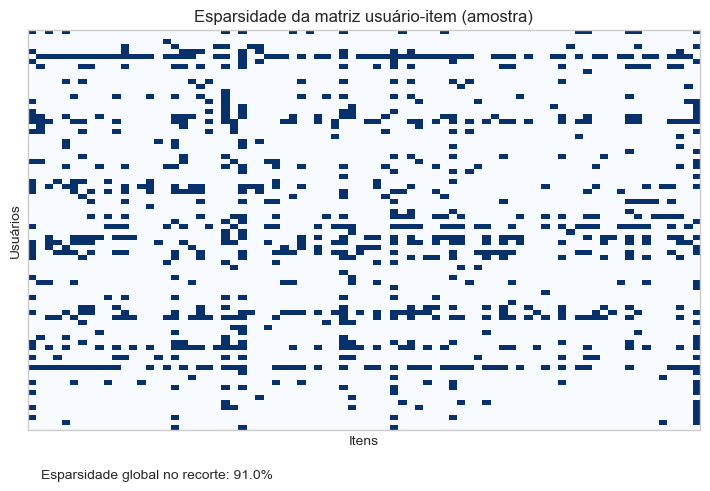

In [4]:
# Figura 1: esparsidade em uma submatriz
amostra = user_item.iloc[:80, :80].notna().astype(int)
fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.imshow(amostra, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_title("Esparsidade da matriz usuário-item (amostra)")
ax.set_xlabel("Itens")
ax.set_ylabel("Usuários")
ax.set_xticks([])
ax.set_yticks([])
ax.text(0.02, -0.12, f"Esparsidade global no recorte: {esparsidade:.1%}", transform=ax.transAxes)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig01_esparsidade.png", dpi=180, bbox_inches="tight")
plt.show()

## Similaridade do cosseno

Para comparar dois itens, olhamos seus vetores de avaliações pelos usuários.

$$
\operatorname{sim}(a,b)=\frac{a \cdot b}{\|a\|\,\|b\|}
$$

Intuição: dois itens são parecidos se recebem padrões de avaliação parecidos entre os usuários.

Em Engenharia, isso equivale a dizer que dois sensores, equipamentos ou procedimentos são similares se aparecem em contextos de uso e avaliação parecidos.

In [5]:
# Divisão treino/teste por usuário.
# Mantemos parte das avaliações de cada usuário para teste quando ele tem histórico suficiente.
def split_por_usuario(df, test_size=0.2, min_interacoes=5, random_state=42):
    rng_local = np.random.default_rng(random_state)
    train_idx, test_idx = [], []
    for _, grupo in df.groupby("userId"):
        idx = grupo.index.to_numpy()
        if len(idx) < min_interacoes:
            train_idx.extend(idx)
            continue
        n_test = max(1, int(round(test_size * len(idx))))
        escolhidos_teste = rng_local.choice(idx, size=n_test, replace=False)
        test_set = set(escolhidos_teste)
        test_idx.extend(escolhidos_teste)
        train_idx.extend([i for i in idx if i not in test_set])
    return df.loc[train_idx].copy(), df.loc[test_idx].copy()

train, test = split_por_usuario(ratings, random_state=RANDOM_STATE)
train_matrix = train.pivot_table(index="userId", columns="movieId", values="rating")
train_matrix = train_matrix.reindex(index=user_item.index, columns=user_item.columns)

print(train.shape, test.shape)
print(f"Usuários com teste: {test['userId'].nunique()}")

(52737, 4) (13186, 4)
Usuários com teste: 609


In [6]:
# Similaridade item-item por cosseno, calculada explicitamente com NumPy.
# Preenchemos valores ausentes com zero para indicar ausência de avaliação observada.
item_user_matrix = train_matrix.fillna(0).T

X = item_user_matrix.to_numpy(dtype=float)
normas = np.linalg.norm(X, axis=1, keepdims=True)
X_norm = np.divide(X, normas, out=np.zeros_like(X), where=normas > 0)
similaridade = X_norm @ X_norm.T
np.fill_diagonal(similaridade, 0.0)

sim_df = pd.DataFrame(similaridade, index=item_user_matrix.index, columns=item_user_matrix.index)

sim_df.iloc[:5, :5]


movieId,1,2,3,5,6
movieId,,,,,
1,0.000000,0.350908,0.281987,0.296271,0.284444
2,0.350908,0.000000,0.216096,0.216812,0.244968
3,0.281987,0.216096,0.000000,0.370165,0.192952
5,0.296271,0.216812,0.370165,0.000000,0.254897
6,0.284444,0.244968,0.192952,0.254897,0.000000


In [7]:
def titulo_filme(movie_id):
    linha = movies_raw.loc[movies_raw["movieId"] == movie_id, "title"]
    return linha.iloc[0] if len(linha) else str(movie_id)


def buscar_movie_id_por_titulo(texto):
    encontrados = movies_raw[movies_raw["title"].str.contains(texto, case=False, regex=False, na=False)]
    if encontrados.empty:
        raise ValueError(f"Nenhum item encontrado contendo: {texto}")
    return int(encontrados.iloc[0]["movieId"])


def itens_similares_cosine(movie_id, n=10):
    if movie_id not in sim_df.index:
        raise ValueError("Item fora do recorte usado na matriz.")
    sims = sim_df[movie_id].sort_values(ascending=False).head(n)
    return pd.DataFrame({
        "movieId": sims.index,
        "titulo": [titulo_filme(mid) for mid in sims.index],
        "similaridade": sims.values,
    })

# Exemplo clássico: Toy Story costuma estar no recorte popular.
movie_id_exemplo = buscar_movie_id_por_titulo("Toy Story") if dataset_nome.startswith("MovieLens") else 1
print(titulo_filme(movie_id_exemplo))
itens_similares_cosine(movie_id_exemplo, n=8)

Toy Story (1995)


,movieId,titulo,similaridade
0,3114,Toy Story 2 (1999),0.491296
1,1210,Star Wars: Episode VI - Return of the Jedi (1983),0.485552
2,588,Aladdin (1992),0.471446
3,788,"Nutty Professor, The (1996)",0.451675
4,34,Babe (1995),0.444210
5,648,Mission: Impossible (1996),0.442048
6,4886,"Monsters, Inc. (2001)",0.442010
7,1265,Groundhog Day (1993),0.438121


## Cálculo explícito nesta aula

Não usamos uma biblioteca especializada de recomendação. O recomendador item-item é implementado passo a passo no notebook para deixar a mecânica visível:

- matriz usuário-item;
- vetores item-usuário;
- similaridade do cosseno calculada com NumPy;
- score normalizado;
- remoção de itens já vistos;
- ranking final.

Isso torna claro de onde sai cada número usado nos gráficos e nas recomendações.


In [8]:
# Exemplo: itens mais parecidos com um filme de referência usando a matriz de similaridade.
def itens_similares(movie_id, n=8):
    if movie_id not in sim_df.index:
        return pd.DataFrame(columns=["movieId", "titulo", "similaridade"])
    similares = sim_df.loc[movie_id].sort_values(ascending=False).head(n)
    return pd.DataFrame({
        "movieId": similares.index,
        "titulo": [titulo_filme(mid) for mid in similares.index],
        "similaridade": similares.values,
    })

filme_referencia = int(item_user_matrix.index[0])
itens_similares(filme_referencia, n=8)

,movieId,titulo,similaridade
0,3114,Toy Story 2 (1999),0.491296
1,1210,Star Wars: Episode VI - Return of the Jedi (1983),0.485552
2,588,Aladdin (1992),0.471446
3,788,"Nutty Professor, The (1996)",0.451675
4,34,Babe (1995),0.444210
5,648,Mission: Impossible (1996),0.442048
6,4886,"Monsters, Inc. (2001)",0.442010
7,1265,Groundhog Day (1993),0.438121


## Score de recomendação item-item

Para um usuário (u) e um item candidato (i), usamos a mesma fórmula implementada no código:

$$
\operatorname{score}(u,i)=
\frac{\sum_{j \in I_u}\operatorname{sim}(i,j)R_{u,j}}{\sum_{j \in I_u}|\operatorname{sim}(i,j)|}
$$

em que:

- (u) é o usuário para quem queremos recomendar;
- (i) é um filme candidato que o usuário ainda não avaliou;
- ($I_u$) é o conjunto de filmes já avaliados por esse usuário no treino;
- (j) é um desses filmes já conhecidos;
- ($\operatorname{sim}(i,j)$) é a similaridade de cosseno entre o candidato (i) e o filme conhecido (j);
- ($R_{u,j}$) é a nota que o usuário (u) deu ao filme (j).

O numerador soma as contribuições dos filmes conhecidos. O denominador normaliza pela soma das similaridades absolutas, reduzindo o efeito de usuários com muitos filmes avaliados.


In [9]:
def recomendar_item_item(user_id, k=10):
    if user_id not in train_matrix.index:
        return pd.DataFrame(columns=["movieId", "titulo", "score"])
    notas_usuario = train_matrix.loc[user_id]
    itens_vistos = notas_usuario.dropna().index
    vetor_notas = notas_usuario.fillna(0).reindex(sim_df.columns).values
    indicador = notas_usuario.notna().astype(float).reindex(sim_df.columns).values

    scores = sim_df.values @ vetor_notas
    normalizador = np.abs(sim_df.values) @ indicador
    scores = np.divide(scores, normalizador, out=np.zeros_like(scores), where=normalizador > 0)

    resultado = pd.DataFrame({"movieId": sim_df.index, "score": scores})
    resultado = resultado[~resultado["movieId"].isin(itens_vistos)]
    resultado = resultado.sort_values("score", ascending=False).head(k)
    resultado["titulo"] = resultado["movieId"].apply(titulo_filme)
    return resultado[["movieId", "titulo", "score"]]

usuario_exemplo = int(train.groupby("userId").size().sort_values(ascending=False).index[0])
print(f"Usuário exemplo: {usuario_exemplo}")
recomendar_item_item(usuario_exemplo, k=10)

Usuário exemplo: 414


,movieId,titulo,score
1002,44555,"Lives of Others, The (Das leben der Anderen) (2006)",3.945633
311,1233,"Boot, Das (Boat, The) (1981)",3.936130
581,2599,Election (1999),3.932415
280,1175,Delicatessen (1991),3.932194
236,926,All About Eve (1950),3.915419
216,866,Bound (1996),3.909560
281,1179,"Grifters, The (1990)",3.907575
1140,92259,Intouchables (2011),3.905301
513,2186,Strangers on a Train (1951),3.905040
1160,105504,Captain Phillips (2013),3.903765


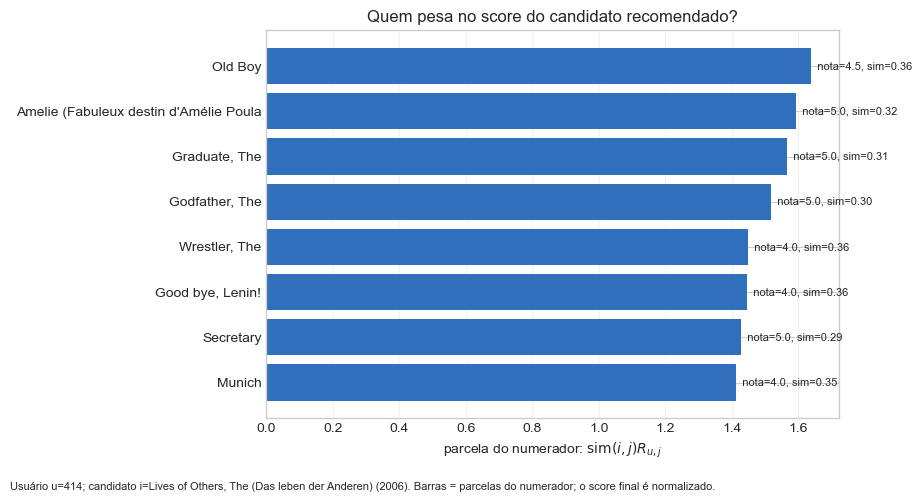

,movieId_j,filme_j,R_u_j,sim_i_j,contribuicao
671,27773,Old Boy (2003),4.5,0.364152,1.638683
571,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",5.0,0.318472,1.592362
218,1247,"Graduate, The (1967)",5.0,0.313349,1.566745
149,858,"Godfather, The (1972)",5.0,0.303273,1.516364
766,64839,"Wrestler, The (2008)",4.0,0.361793,1.447172
646,7323,"Good bye, Lenin! (2003)",4.0,0.361154,1.444616
594,5617,Secretary (2002),5.0,0.285515,1.427576
698,41997,Munich (2005),4.0,0.352821,1.411284


In [10]:
# Figura 4: decomposição visual do score para um usuário real do MovieLens.
def decompor_score(user_id, movie_id, top_n=8):
    notas_usuario = train_matrix.loc[user_id].dropna()
    sims = sim_df.loc[movie_id, notas_usuario.index]
    partes = pd.DataFrame({
        "movieId_j": notas_usuario.index,
        "filme_j": [titulo_filme(mid) for mid in notas_usuario.index],
        "R_u_j": notas_usuario.values,
        "sim_i_j": sims.values,
    })
    partes["contribuicao"] = partes["R_u_j"] * partes["sim_i_j"]
    partes = partes.sort_values("contribuicao", ascending=False)
    return partes.head(top_n)

usuario_exemplo = int(train_matrix.count(axis=1).sort_values(ascending=False).index[0])
recs_exemplo = recomendar_item_item(usuario_exemplo, k=5)
filme_candidato = int(recs_exemplo.iloc[0]["movieId"])
partes_score = decompor_score(usuario_exemplo, filme_candidato, top_n=8)

fig, ax = plt.subplots(figsize=(9.2, 5.0))
plot_partes = partes_score.iloc[::-1].copy()
rotulos = plot_partes["filme_j"].str.replace(r"\s*\(\d{4}\)", "", regex=True).str.slice(0, 38)
ax.barh(rotulos, plot_partes["contribuicao"], color="#2f6fbb")
ax.set_xlabel(r"parcela do numerador: $\operatorname{sim}(i,j)R_{u,j}$")
ax.set_title("Quem pesa no score do candidato recomendado?")
ax.grid(axis="x", alpha=0.25)
for y_pos, (_, row) in enumerate(plot_partes.iterrows()):
    ax.text(row["contribuicao"], y_pos, f"  nota={row['R_u_j']:.1f}, sim={row['sim_i_j']:.2f}", va="center", fontsize=8)
fig.text(
    0.01, 0.01,
    f"Usuário u={usuario_exemplo}; candidato i={titulo_filme(filme_candidato)}. Barras = parcelas do numerador; o score final é normalizado.",
    fontsize=8,
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIG_DIR / "fig04_score_decomposicao.png", dpi=180, bbox_inches="tight")
plt.show()

partes_score[["movieId_j", "filme_j", "R_u_j", "sim_i_j", "contribuicao"]]


In [11]:
# Baseline de popularidade: recomenda itens bem avaliados e com muitas avaliações.
# A ideia didática é simples: antes de personalizar, veja quão forte é recomendar o que já é muito aceito.
pop_stats = train.groupby("movieId").agg(
    media=("rating", "mean"),
    n_avaliacoes=("rating", "size")
).reset_index()
pop_stats["score_popularidade"] = pop_stats["media"] * np.log1p(pop_stats["n_avaliacoes"])
pop_ranking = pop_stats.sort_values("score_popularidade", ascending=False)


def recomendar_popularidade(user_id, k=10):
    vistos = set(train.loc[train["userId"] == user_id, "movieId"])
    recs = pop_ranking[~pop_ranking["movieId"].isin(vistos)].head(k).copy()
    recs["titulo"] = recs["movieId"].apply(titulo_filme)
    return recs[["movieId", "titulo", "media", "n_avaliacoes", "score_popularidade"]]

pop_ranking.head(10).assign(titulo=lambda d: d["movieId"].apply(titulo_filme))[
    ["movieId", "titulo", "media", "n_avaliacoes", "score_popularidade"]
]


,movieId,titulo,media,n_avaliacoes,score_popularidade
98,318,"Shawshank Redemption, The (1994)",4.408163,245,24.268400
112,356,Forrest Gump (1994),4.117424,264,22.974115
91,296,Pulp Fiction (1994),4.158996,239,22.793954
576,2571,"Matrix, The (1999)",4.193694,222,22.676022
171,593,"Silence of the Lambs, The (1991)",4.146119,219,22.362620
79,260,Star Wars: Episode IV - A New Hope (1977),4.210256,195,22.222216
636,2959,Fight Club (1999),4.231638,177,21.927434
286,1196,Star Wars: Episode V - The Empire Strikes Back (1980),4.218391,174,21.787086
25,50,"Usual Suspects, The (1995)",4.227273,165,21.609767
153,527,Schindler's List (1993),4.197605,167,21.508376


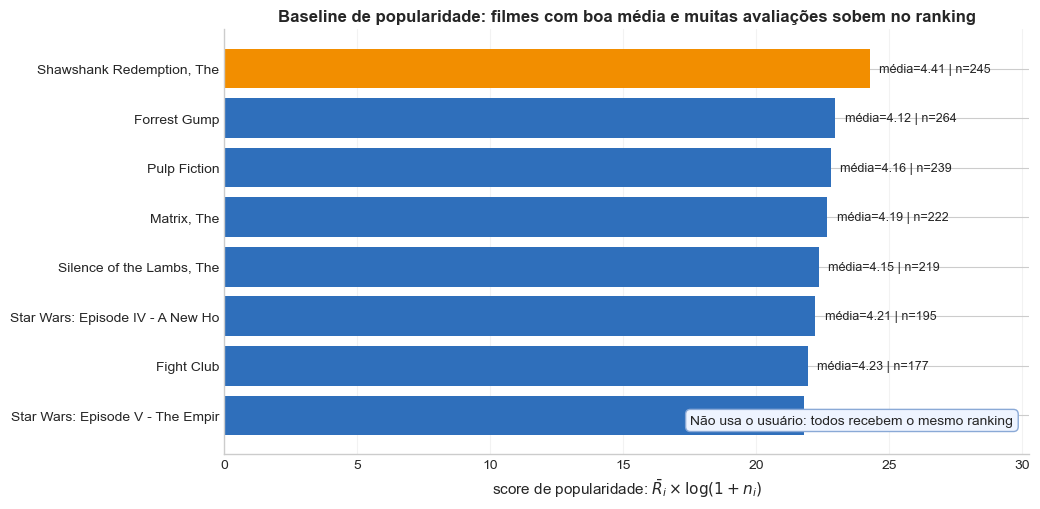

In [12]:
# Figura 2: baseline de popularidade com ranking legível.
mais_populares = pop_ranking.head(8).copy()
mais_populares["titulo_curto"] = mais_populares["movieId"].apply(titulo_filme).str.replace(r"\s*\(\d{4}\)", "", regex=True)
mais_populares["titulo_curto"] = mais_populares["titulo_curto"].str.slice(0, 32)

y = np.arange(len(mais_populares))[::-1]
fig, ax = plt.subplots(figsize=(10.5, 5.2))
cores = ["#f28e00" if i == 0 else "#2f6fbb" for i in range(len(mais_populares))]
ax.barh(y, mais_populares["score_popularidade"], color=cores)
ax.set_yticks(y)
ax.set_yticklabels(mais_populares["titulo_curto"], fontsize=10)
ax.set_xlabel(r"score de popularidade: $\bar{R}_i \times \log(1+n_i)$", fontsize=11)
ax.set_title("Baseline de popularidade: filmes com boa média e muitas avaliações sobem no ranking", fontsize=12, weight="bold")
ax.grid(axis="x", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

for pos, (_, row) in zip(y, mais_populares.iterrows()):
    label = f"média={row['media']:.2f} | n={int(row['n_avaliacoes'])}"
    ax.text(row["score_popularidade"] + 0.35, pos, label, va="center", fontsize=9)

limite = mais_populares["score_popularidade"].max() + 6
ax.set_xlim(0, limite)
ax.text(
    0.98, 0.08,
    "Não usa o usuário: todos recebem o mesmo ranking",
    transform=ax.transAxes, ha="right", va="center", fontsize=10,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "#eef4ff", "edgecolor": "#8aa9d6"},
)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_popularidade.png", dpi=180, bbox_inches="tight")
plt.show()


## Avaliação: Precision@K

Em recomendação, avaliamos a qualidade do ranking. Para cada usuário, olhamos os (K) primeiros itens recomendados e contamos quantos deles eram relevantes no teste.

$$
\operatorname{Precision@K}=\frac{\text{itens relevantes recomendados no Top K}}{K}
$$

Aqui, um filme é considerado relevante se aparece no conjunto de teste com nota maior ou igual a 4.0.

Exemplo: se (K=10) e 3 dos 10 filmes recomendados eram relevantes, então ($\operatorname{Precision@10}=3/10=0{,}30)$.

Essa métrica não é acurácia de classificação. Ela pergunta: **o topo da lista contém boas recomendações?**


In [13]:
def precision_at_k(recomendados, relevantes, k):
    recomendados_k = list(recomendados)[:k]
    if k == 0:
        return 0.0
    return len(set(recomendados_k) & set(relevantes)) / k


def avaliar_modelo(func_recomendar, ks=(5, 10, 20), limiar_relevancia=4.0):
    relevantes_por_usuario = (
        test[test["rating"] >= limiar_relevancia]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )
    linhas = []
    for k in ks:
        valores = []
        for user_id, relevantes in relevantes_por_usuario.items():
            if not relevantes:
                continue
            recs = func_recomendar(user_id, k=k)
            valores.append(precision_at_k(recs["movieId"].tolist(), relevantes, k))
        linhas.append({
            "K": k,
            "Precision@K": float(np.mean(valores)) if valores else 0.0,
            "usuarios_avaliados": len(valores),
        })
    return pd.DataFrame(linhas)

avaliacao_item = avaliar_modelo(recomendar_item_item)
avaliacao_item["modelo"] = "Item-item"
avaliacao_pop = avaliar_modelo(recomendar_popularidade)
avaliacao_pop["modelo"] = "Popularidade"
avaliacao = pd.concat([avaliacao_item, avaliacao_pop], ignore_index=True)
avaliacao


,K,Precision@K,usuarios_avaliados,modelo
0,5,0.013153,593,Item-item
1,10,0.018550,593,Item-item
2,20,0.020826,593,Item-item
3,5,0.164587,593,Popularidade
4,10,0.129005,593,Popularidade
5,20,0.099578,593,Popularidade


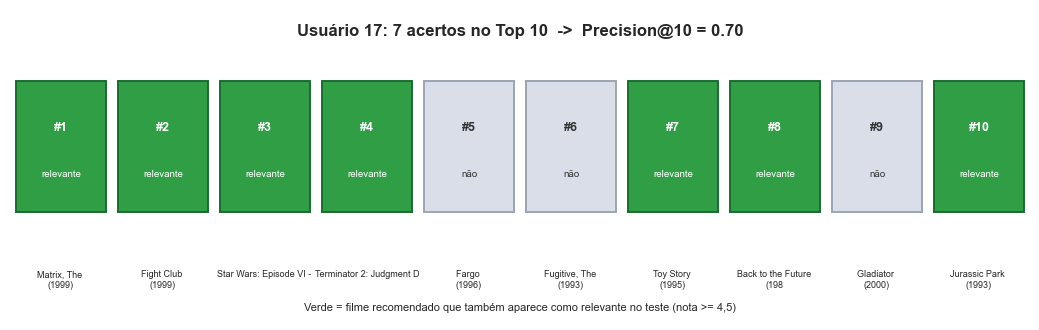

In [14]:
# Figura 6: exemplo visual de Precision@10 usando recomendações reais.
def encontrar_exemplo_precision(func_recomendar, k=10, limiar_relevancia=4.0):
    relevantes_por_usuario = (
        test[test["rating"] >= limiar_relevancia]
        .groupby("userId")["movieId"]
        .apply(set)
        .to_dict()
    )
    melhor = None
    for user_id, relevantes in relevantes_por_usuario.items():
        recs = func_recomendar(user_id, k=k)
        if recs.empty:
            continue
        hits = [mid in relevantes for mid in recs["movieId"].tolist()[:k]]
        n_hits = sum(hits)
        if melhor is None or n_hits > melhor["n_hits"]:
            melhor = {"user_id": user_id, "recs": recs.head(k).copy(), "hits": hits, "n_hits": n_hits, "relevantes": relevantes}
    return melhor

ex_prec = encontrar_exemplo_precision(recomendar_popularidade, k=10, limiar_relevancia = 4.5)
fig, ax = plt.subplots(figsize=(10.5, 3.4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.axis("off")
for pos, (_, row) in enumerate(ex_prec["recs"].iterrows()):
    hit = ex_prec["hits"][pos]
    color = "#2f9e44" if hit else "#d9dee8"
    edge = "#1b6b31" if hit else "#9aa4b2"
    rect = plt.Rectangle((pos + 0.06, 0.35), 0.88, 0.42, facecolor=color, edgecolor=edge, linewidth=1.4)
    ax.add_patch(rect)
    ax.text(pos + 0.50, 0.62, f"#{pos+1}", ha="center", va="center", fontsize=9, weight="bold", color="white" if hit else "#333333")
    ax.text(pos + 0.50, 0.47, "relevante" if hit else "não", ha="center", va="center", fontsize=7, color="white" if hit else "#333333")
    titulo = titulo_filme(int(row["movieId"])).replace("(", "\n(")
    ax.text(pos + 0.50, 0.16, titulo[:24], ha="center", va="top", fontsize=6.5)
precision_exemplo = ex_prec["n_hits"] / 10
ax.text(5, 0.93, f"Usuário {ex_prec['user_id']}: {ex_prec['n_hits']} acertos no Top 10  ->  Precision@10 = {precision_exemplo:.2f}", ha="center", va="center", fontsize=12, weight="bold")
ax.text(5, 0.03, "Verde = filme recomendado que também aparece como relevante no teste (nota >= 4,5)", ha="center", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig06_precision_exemplo.png", dpi=180, bbox_inches="tight")
plt.show()


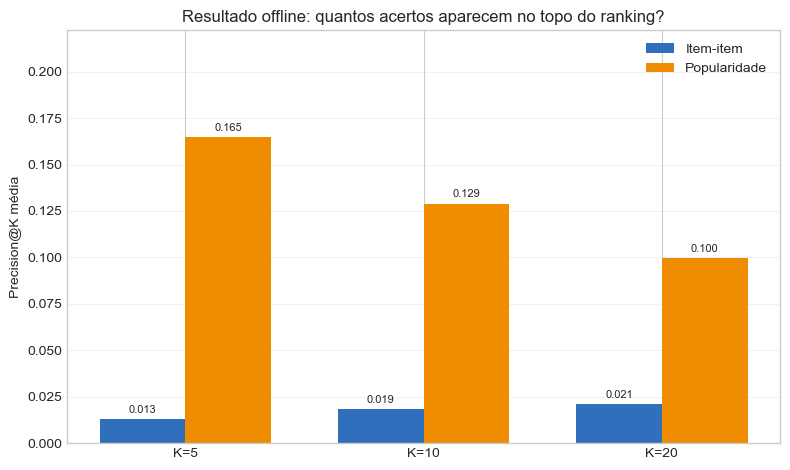

modelo,K,Item-item,Popularidade
0,5,0.013153,0.164587
1,10,0.018550,0.129005
2,20,0.020826,0.099578


In [15]:
# Figura 3: comparação de Precision@K em barras agrupadas.
fig, ax = plt.subplots(figsize=(8.0, 4.8))
modelos = ["Item-item", "Popularidade"]
ks = sorted(avaliacao["K"].unique())
x = np.arange(len(ks))
largura = 0.36
cores = {"Item-item": "#2f6fbb", "Popularidade": "#f08c00"}

for offset, modelo in zip([-largura/2, largura/2], modelos):
    grupo = avaliacao[avaliacao["modelo"] == modelo].set_index("K").loc[ks]
    barras = ax.bar(x + offset, grupo["Precision@K"], largura, label=modelo, color=cores[modelo])
    ax.bar_label(barras, labels=[f"{v:.3f}" for v in grupo["Precision@K"]], padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in ks])
ax.set_ylabel("Precision@K média")
ax.set_title("Resultado offline: quantos acertos aparecem no topo do ranking?")
ax.set_ylim(0, max(avaliacao["Precision@K"]) * 1.35)
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig03_precision_k.png", dpi=180, bbox_inches="tight")
plt.show()

avaliacao_pivot = avaliacao.pivot(index="K", columns="modelo", values="Precision@K").reset_index()
avaliacao_pivot


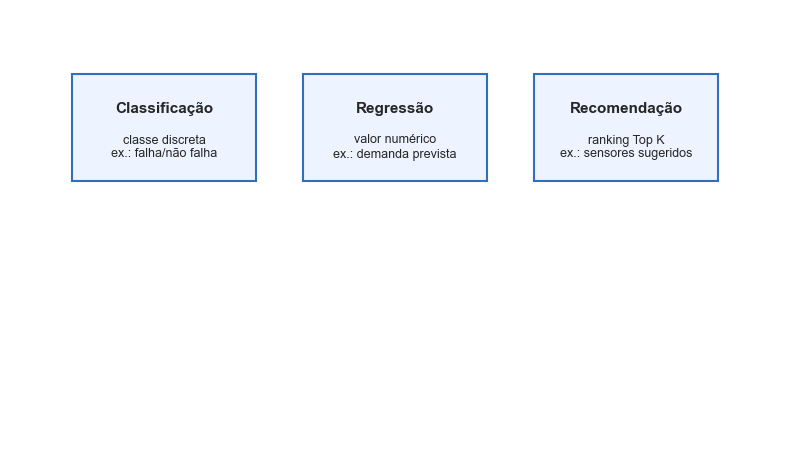

In [17]:
# Figura 5: comparação conceitual entre tarefas
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.axis("off")
caixas = [
    (0.08, 0.60, "Classificação", "classe discreta\nex.: falha/não falha"),
    (0.38, 0.60, "Regressão", "valor numérico\nex.: demanda prevista"),
    (0.68, 0.60, "Recomendação", "ranking Top K\nex.: sensores sugeridos"),
]
for x, y, titulo, texto in caixas:
    rect = plt.Rectangle((x, y), 0.24, 0.25, facecolor="#eef4ff", edgecolor="#2f6fbb", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.12, y + 0.17, titulo, ha="center", va="center", weight="bold", fontsize=11)
    ax.text(x + 0.12, y + 0.08, texto, ha="center", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig05_tarefas_ml.png", dpi=180, bbox_inches="tight")
plt.show()